<a href="https://colab.research.google.com/github/abeerahateeq/neurofive-ml-track/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Titanic Dataset - Initial Data Story

The Titanic dataset contains **891 rows** and **12 columns**. During the initial exploration, I found missing values in the **Age (177)**, **Cabin (687)**, and **Embarked (2)** columns, while the remaining columns are complete. The dataset consists of both numerical and categorical features, including passenger demographics, ticket information, and survival status. This initial analysis shows that data cleaning, especially handling missing values and categorical variables, will be an important preprocessing step before building machine learning models.

In [11]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Upload train.csv
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("train.csv")

# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)

# Display the first 5 rows
df.head()

Saving train.csv to train (1).csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 11


In [16]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set_style("whitegrid")

## Resources

## Model Comparison

| Model | Accuracy |
|--------|---------:|
| Original Logistic Regression | 78.21% |
| Tuned Logistic Regression | 78.21% |

The tuned model was evaluated after optimizing the hyperparameters using GridSearchCV. Hyperparameter tuning helps identify the best configuration for a model by systematically testing different parameter combinations instead of relying on default values.

### Preparing Data for Modeling

In [18]:
# Convert categorical features into numerical (one-hot encoding)
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Drop columns from df_encoded that are not useful for prediction
df_encoded = df_encoded.drop(columns=['Name', 'Ticket'])

# Display the first 5 rows of the encoded dataframe
display(df_encoded.head())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


### Splitting the Data into Training and Testing Sets

In [19]:
X = df_encoded.drop(['Survived', 'PassengerId'], axis=1)
y = df_encoded['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 712 samples
Test set size: 179 samples


### Building and Evaluating a Logistic Regression Model

In [20]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [21]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("Confusion Matrix:")
print(conf_matrix)

Model Accuracy: 78.21%
Confusion Matrix:
[[89 16]
 [23 51]]


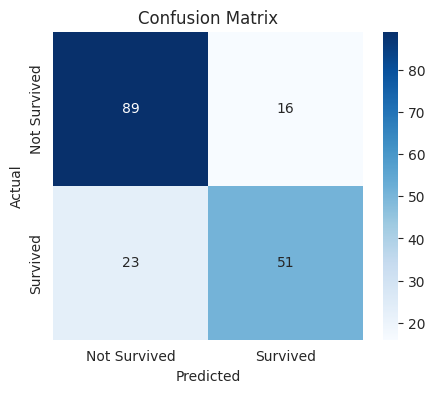

In [22]:
plt.figure(figsize=(5,4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
print("Classification Report for initial model:")
print(classification_report(y_test, y_pred))

Classification Report for initial model:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



## Why Accuracy Alone Can Be Misleading

Accuracy only tells us the percentage of correct predictions made by the model. If one class appears much more frequently than another, a model can achieve high accuracy simply by predicting the majority class every time.

Precision measures how many predicted positive cases were actually correct, while Recall measures how many actual positive cases the model successfully identified. The F1-score balances Precision and Recall, making it especially useful when evaluating models on datasets where the classes are not perfectly balanced.

## Model Evaluation

The Logistic Regression model achieved an accuracy of **78.21%** on the test dataset.

### Confusion Matrix

|                | Predicted: Did Not Survive | Predicted: Survived |
|----------------|---------------------------:|--------------------:|
| **Actual: Did Not Survive** | 89 | 16 |
| **Actual: Survived** | 23 | 51 |

### Interpretation

The confusion matrix shows that the model correctly identified **89 passengers who did not survive** and **51 passengers who survived**. However, it incorrectly predicted that **16 passengers survived when they did not** (false positives) and predicted that **23 passengers did not survive when they actually survived** (false negatives).

Overall, the model correctly classified **140 out of 179 passengers**, resulting in an accuracy of **78.21%**. While the model performs well, the confusion matrix highlights areas where prediction errors still occur, suggesting there is room for improvement through feature engineering or by trying more advanced machine learning algorithms.

### Hyperparameter Tuning with GridSearchCV

To further improve the model, I will perform hyperparameter tuning using `GridSearchCV`. This will systematically work through multiple combinations of parameters, cross-validating each combination to determine which one performs the best.

In [30]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.2%}")

Best parameters: {'C': 1, 'solver': 'liblinear'}
Best cross-validation accuracy: 79.63%


In [31]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'solver': 'liblinear'}

Best Cross Validation Score:
0.7962966610853935


### Evaluate the Best Model

In [24]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy: {accuracy_tuned:.2%}")
print("Tuned Confusion Matrix:")
print(conf_matrix_tuned)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy: 78.21%
Tuned Confusion Matrix:
[[89 16]
 [23 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



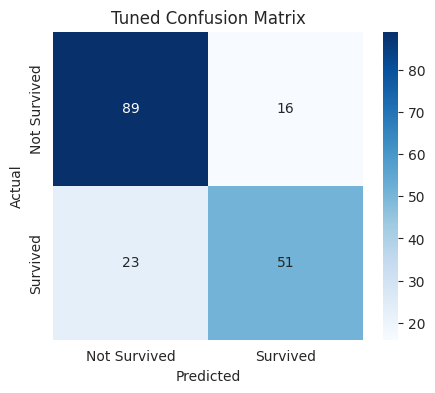

In [25]:
plt.figure(figsize=(5,4))
sns.heatmap(
    conf_matrix_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Confusion Matrix")
plt.show()

In [26]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handling Missing Values

Based on the previous analysis, we will handle the missing values in the following ways:

*   **Age**: Fill missing values with the median age.
*   **Embarked**: Fill missing values with the most frequent (mode) embarkation port.
*   **Cabin**: Drop the entire 'Cabin' column due to a large number of missing values (687 out of 891).

In [28]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# The 'Cabin' column was already dropped in the initial data loading cell (8fTpi0jyi7Qp)
# No need to drop it again.

# Verify the changes
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Justification for Missing Value Handling

*   The **Age** column contained 177 missing values, so I filled them with the median because it is less affected by extreme values than the mean.
*   The **Embarked** column had only two missing values, so I replaced them with the most frequent category (mode).
*   The **Cabin** column contained 687 missing values, which is over 77% of the dataset, so I removed it because imputing so many values would likely introduce significant bias.

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Passengers")
plt.show()

In [ ]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Which feature do you think most affects survival, and why?

Based on the visualizations, **Sex** appears to have the strongest influence on survival. Female passengers had a much higher survival rate than male passengers, which reflects the historical evacuation practice of prioritizing women and children during the Titanic disaster. Passenger class (Pclass) also seems to affect survival, as first-class passengers generally had better access to lifeboats and higher survival rates.